### README

In [100]:
# 221900180 田永铭
# 说明：我使用神经网络在泰坦尼克数据集测试集上达到了79.90%的准确率

# 在这份代码中我完成了：
# 1.数据探索（于统计描述、缺失值检查、异常值检测）
# 2.分析各个变量与生存率之间的关系
# 3.基于数据探索和关系进行数据预处理（填充缺失值，清洗数据等等）
# 4.定义神经网络，考虑了采用dropout来减少过拟合，在训练集上采用K折交叉验证进行模型训练和选择，因为训练集样本太少了，所以用这种方法能有效提高准确率
# 5.使用训练好的神经网络在测试集上做预测，最好达到了79.90%的准确率（这是跑了大概5次的结果，总体准确率在77%到79.9%之间）

### 0. 导入所需库和加载数据集

In [101]:
# 导入所需库
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 加载数据集（其中测试集label只有在测试的时候才用到）（如果验证，请注意命名方式！！都是默认的！！！）
train_df = pd.read_csv("./train.csv")
test_df = pd.read_csv("./test.csv")
# 加载实际标签（测试集标签）
label_df = pd.read_csv('./submission.csv')

### 1. 数据探索

In [102]:
# 首先进行统计描述

# 查看训练数据的前几行
train_df.head()

# 查看训练数据的基本信息
train_df.info()

# 统计缺失值情况
train_df.isnull().sum()

# 获取数值型变量的统计描述
train_df.describe()

# 据观察，Age、Cabin、Embarked存在缺失值，其中Cabin缺失值较多，可以考虑删除

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [103]:
# 利用箱线图检测异常值，这部分我尝试了，但是发现准确率不会提高，因此最终没有采用

def detect_outliers(df, columns):
    outliers = {}
    bounds = {}
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        real_lower_bound = Q1 - 2 * IQR # 调整了一下值
        real_upper_bound = Q3 + 2 * IQR
        outliers[column] = df[(df[column] < real_lower_bound) | (df[column] > real_upper_bound)][column]
        bounds[column] = (real_lower_bound, real_upper_bound)  # 保存上下界
    return outliers, bounds

# 选择数值型变量进行异常值检测，有两列因为只是简单的个别整数，不做处理
numeric_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = [col for col in numeric_columns if (col != 'Parch' and col != 'SibSp')]  # 排除 "Parch" 和 "SilSp" 列

# 检测异常值
outliers, bounds = detect_outliers(train_df, numeric_columns)

# 输出异常值检测结果
for column, values in outliers.items():
    print(f"Column: {column}, Number of Outliers: {len(values)}")
    print(values)

# # 使用上下界替换异常值
# for column, values in outliers.items():
#     lower_bound, upper_bound = bounds[column]
#     # 将列转换为 float64 类型以避免类型不匹配警告
#     train_df[column] = train_df[column].astype('float64')
    
#     # 将低于下界的值替换为下界，将高于上界的值替换为上界
#     train_df.loc[train_df[column] < lower_bound, column] = lower_bound
#     train_df.loc[train_df[column] > upper_bound, column] = upper_bound


Column: PassengerId, Number of Outliers: 0
Series([], Name: PassengerId, dtype: int64)
Column: Survived, Number of Outliers: 0
Series([], Name: Survived, dtype: int64)
Column: Pclass, Number of Outliers: 0
Series([], Name: Pclass, dtype: int64)
Column: Age, Number of Outliers: 2
630    80.0
851    74.0
Name: Age, dtype: float64
Column: Fare, Number of Outliers: 92
27     263.0000
31     146.5208
34      82.1708
61      80.0000
62      83.4750
         ...   
829     80.0000
835     83.1583
849     89.1042
856    164.8667
879     83.1583
Name: Fare, Length: 92, dtype: float64


### 2. 相关性分析

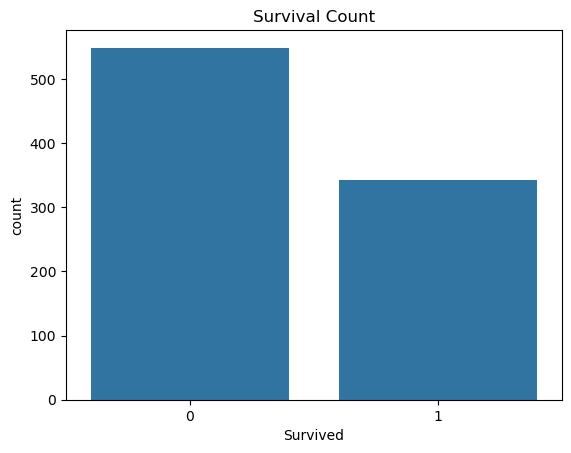

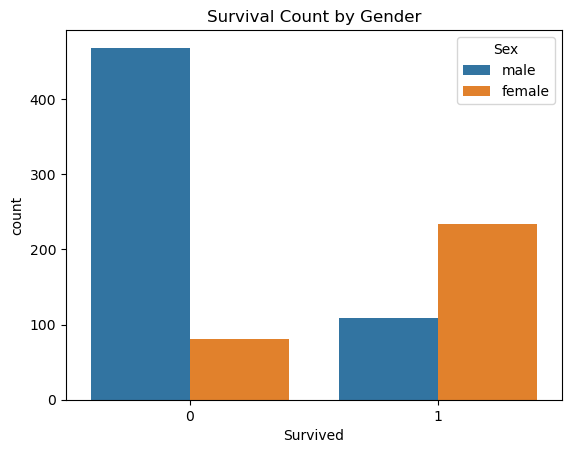

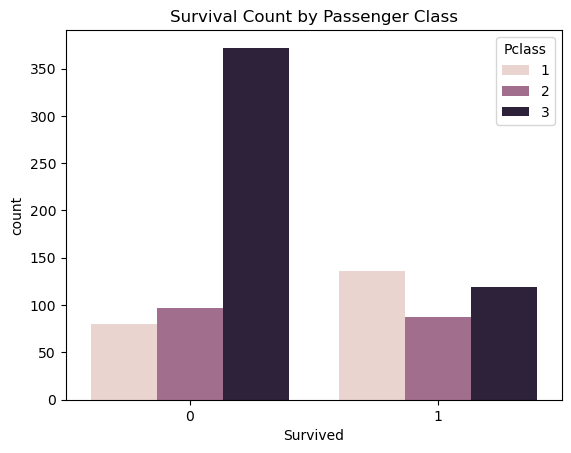

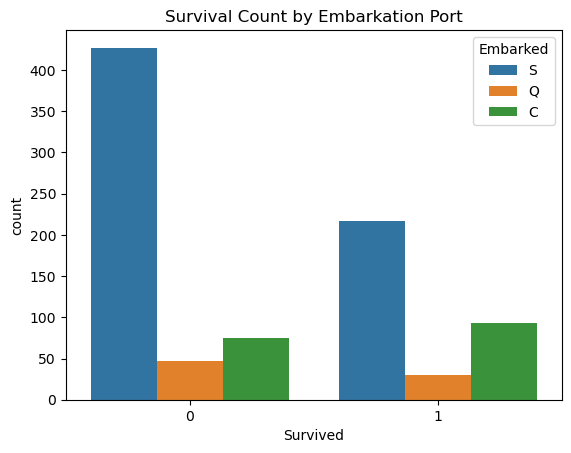

In [104]:
# 计算并显示各个变量与生存率的相关性
sns.countplot(x='Survived', data=train_df)
plt.title("Survival Count")
plt.show()

# 查看性别与生存率的关系
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title("Survival Count by Gender")
plt.show()

# 查看客舱等级与生存率的关系
sns.countplot(x='Survived', hue='Pclass', data=train_df)
plt.title("Survival Count by Passenger Class")
plt.show()

# 查看登船港口与生存率的关系
sns.countplot(x='Survived', hue='Embarked', data=train_df)
plt.title("Survival Count by Embarkation Port")
plt.show()

# 可以观察到，女性、头等舱、从C港口登船的乘客生存率较高

### 3. 数据预处理

In [105]:
# 这里是写了一个回归模型预测年龄，但是后来发现效果不好，最终也没有采用。年龄还是用的中位数填充

# from sklearn.ensemble import RandomForestRegressor

# # 准备用于预测年龄的特征和标签
# # 使用Pclass, Sex, SibSp, Parch, Fare等列作为特征
# age_features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare']
# # 将Sex列进行编码
# train_df['Sex'] = LabelEncoder().fit_transform(train_df['Sex'])
# test_df['Sex'] = LabelEncoder().fit_transform(test_df['Sex'])

# # 创建训练集和测试集用于填充缺失的年龄值
# train_age_df = train_df[age_features + ['Age']]
# test_age_df = test_df[age_features + ['Age']]

# # 将有年龄缺失值的行分离出来
# train_known_age = train_age_df[train_age_df['Age'].notnull()]
# train_unknown_age = train_age_df[train_age_df['Age'].isnull()]

# # 使用已知年龄的数据训练回归模型
# X = train_known_age[age_features]
# y = train_known_age['Age']
# age_regressor = RandomForestRegressor(random_state=0, n_estimators=100)
# age_regressor.fit(X, y)

# # 使用训练好的模型预测缺失的年龄值
# train_df.loc[train_df['Age'].isnull(), 'Age'] = age_regressor.predict(train_unknown_age[age_features])

# # 同样对测试集的缺失年龄进行预测
# test_known_age = test_age_df[test_age_df['Age'].notnull()]
# test_unknown_age = test_age_df[test_age_df['Age'].isnull()]
# test_df.loc[test_df['Age'].isnull(), 'Age'] = age_regressor.predict(test_unknown_age[age_features])


In [106]:
# 使用中位数填充年龄缺失值
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

# 使用众数填充登船港口缺失值
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

# 使用中位数填充票价缺失值
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

# 将分类特征（性别和登船港口）转换为数值型
label_encoder = LabelEncoder()
train_df['Sex'] = label_encoder.fit_transform(train_df['Sex'])
test_df['Sex'] = label_encoder.transform(test_df['Sex'])

train_df['Embarked'] = label_encoder.fit_transform(train_df['Embarked'])
test_df['Embarked'] = label_encoder.transform(test_df['Embarked'])



C:\Users\86181\AppData\Local\Temp\ipykernel_16788\45137940.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\86181\AppData\Local\Temp\ipykernel_16788\45137940.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [107]:
# 创建一个家庭规模的特征（这个特征比单纯的SibSp和Parch有用）
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

# 选择用于训练的特征和标签
X = train_df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]
y = train_df['Survived']

# 测试数据集的特征
X_test = test_df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]

# 标准化特征
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

### 4. 定义神经网络并且进行k折交叉验证方式的训练，找到一个好的参数

In [108]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
import numpy as np

# 定义K折交叉验证的折数
k = 5  # 例如5折交叉验证

# 创建神经网络模型函数,考虑了采用dropout来减少过拟合
def create_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(16, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# K折交叉验证
kf = KFold(n_splits=k, shuffle=True, random_state=42)
best_val_accuracy = 0  # 用来记录最好的验证准确率
best_history = None  # 保存最好的训练历史
best_model = None  # 保存最好的模型

for train_index, val_index in kf.split(X):
    # 划分数据
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # 创建新的模型实例
    model = create_model()

    # 使用EarlyStopping防止过拟合
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # 训练模型
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                        epochs=50, batch_size=32, callbacks=[early_stopping])

    # 获取当前折的验证准确率
    val_accuracy = history.history['val_accuracy'][-1]

    # 如果当前折的验证准确率更好，则更新最好的模型和历史
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_history = history

history = best_history

Epoch 1/50
23/23 [==============================] - 1s 13ms/step - loss: 0.8409 - accuracy: 0.5562 - val_loss: 0.6425 - val_accuracy: 0.7542
Epoch 2/50
23/23 [==============================] - 0s 3ms/step - loss: 0.7168 - accuracy: 0.6475 - val_loss: 0.6021 - val_accuracy: 0.7821
Epoch 3/50
23/23 [==============================] - 0s 3ms/step - loss: 0.7166 - accuracy: 0.6615 - val_loss: 0.5756 - val_accuracy: 0.7430
Epoch 4/50
23/23 [==============================] - 0s 3ms/step - loss: 0.6618 - accuracy: 0.6756 - val_loss: 0.5571 - val_accuracy: 0.7374
Epoch 5/50
23/23 [==============================] - 0s 3ms/step - loss: 0.5793 - accuracy: 0.7444 - val_loss: 0.5338 - val_accuracy: 0.7486
Epoch 6/50
23/23 [==============================] - 0s 3ms/step - loss: 0.6100 - accuracy: 0.7163 - val_loss: 0.5147 - val_accuracy: 0.7486
Epoch 7/50
23/23 [==============================] - 0s 3ms/step - loss: 0.5841 - accuracy: 0.7247 - val_loss: 0.4996 - val_accuracy: 0.7486
Epoch 8/50
23/23 [=

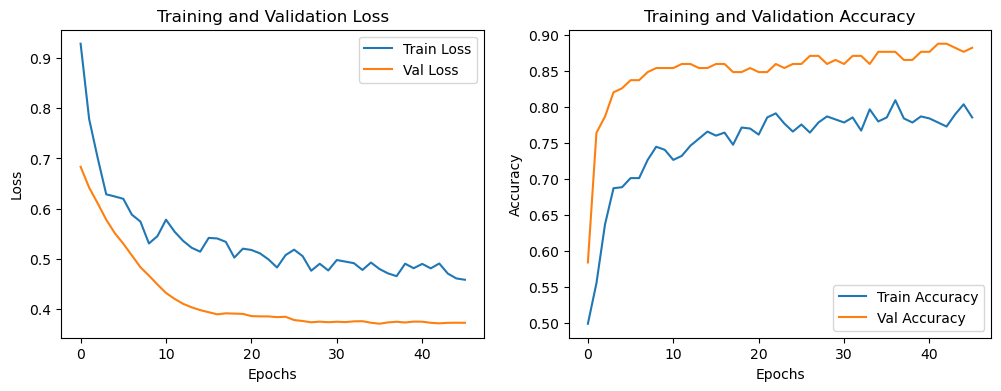

In [109]:
# 绘制训练和验证的损失和准确率

# ！！！！！ 解释一下为什么我的验证集准确率会比训练集准确率高，这是主要因为我使用了EarlyStopping，！！！！！！！！！！
#   所以在验证集上的准确率是最好的，而不是在训练集上的准确率（训练集还没训练充分）
#   这是合理的， 以及训练集噪声可能较大，正则化dropout也抑制了训练集表现

plt.figure(figsize=(12, 4))

# 损失图
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# 准确率图
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.show()

### 5.使用训练好的神经网络在测试集上做预测

In [111]:
#<<<<最好>>>>达到了79.90%的准确率（这是跑了大概5次的结果，总体准确率在77%到79.9%之间）

# 对测试集进行预测
predictions = (model.predict(X_test) > 0.5).astype("int32")

# 将预测结果保存到DataFrame中
output = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': predictions.flatten()})

# 合并预测结果和实际标签
merged_df = output.merge(label_df, on='PassengerId', suffixes=('_pred', '_actual'))

# 计算准确率
accuracy = (merged_df['Survived_pred'] == merged_df['Survived_actual']).mean()

# 打印测试集准确率
print(f'Test accuracy: {accuracy:.4f}')


14/14 [==============================] - 0s 1ms/step
Test accuracy: 0.7990
